# V30: LQ45 Strategy Comparison - No Transaction Fees

This notebook implements the full LQ45 backtest and exports the simulation results into an Excel file, but **without considering transaction fees**.

### Features:
1. **Full Backtest Suite**: Proposed AI Strategy vs Markowitz Benchmarks.
2. **No Transaction Costs**: Fees are set to 0.0% to analyze theoretical performance.
3. **Excel Export**: Saves daily portfolio values and summary metrics to `v30_lq45_portfolio_results_no_fee.xlsx`.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45 Dataset) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) 

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. AI Model Training (Threshold Optimization on Train Data) ---
def find_optimal_threshold(model, X, y, beta=0.5):
    probs = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.3, 0.8, 51)
    scores = [fbeta_score(y, (probs >= t).astype(int), beta=beta) for t in thresholds]
    return thresholds[np.argmax(scores)]

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.dropna()
target = (market_return.shift(-1) > 0).astype(int).reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

print("Training AI Gatekeeper...")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
opt_t = find_optimal_threshold(xgb_model, X_train, y_train)
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Training AI Gatekeeper...
Optimized Threshold: 0.57


In [3]:
# --- 3. Simulation Logic ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, threshold=0.5, fee=0.0, lookback=30):
    """
    Simulation with NO Transaction Fee (fee=0.0)
    """
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-lookback:loc_idx]
        
        if strategy_type == 'Proposed':
            is_risk_off = ai_probs.loc[date] < threshold
            if is_risk_off:
                weights = {'CASH': 1.0}
            else:
                selected = get_mis_assets(window_rets)
                weights = optimize_markowitz(window_rets[selected])
        elif strategy_type == 'Markowitz Only':
            weights = optimize_markowitz(window_rets)
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                static_weights = optimize_markowitz(window_rets)
            weights = static_weights
        
        # Fee Logic (Calculated but set to 0.0 effectively by parameter)
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        prev_weights = weights
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

In [4]:
# --- 4. Execution ---
test_dates = test_probs.index
fee = 0.0 # NO FEE
results = {}

print("Simulating strategies (No Fees)...")
results['AI Proposed LQ45'] = run_simulation('Proposed', test_dates, returns, test_probs, opt_t, fee=fee)
results['Markowitz Active'] = run_simulation('Markowitz Only', test_dates, returns, fee=fee)
results['Markowitz Static'] = run_simulation('Markowitz Static', test_dates, returns, fee=fee)
results['IHSG Benchmark'] = pd.DataFrame({'Portfolio_Value': (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)}, index=test_dates)

print("✓ Backtests Completed.")

Simulating strategies (No Fees)...
✓ Backtests Completed.


In [5]:
# --- 5. Export to Excel ---
output_file = 'v30_lq45_portfolio_results_no_fee.xlsx'
writer = pd.ExcelWriter(output_file, engine='openpyxl')

# 1. Portfolio Values sheet
combined_df = pd.DataFrame(index=test_dates)
for label, df in results.items():
    combined_df[label] = df['Portfolio_Value']
combined_df.to_excel(writer, sheet_name='Portfolio_Values')

# 2. Summary Metrics Sheet
summary = []
for label, df in results.items():
    rets = df['Portfolio_Value'].pct_change().dropna()
    total_ret = (df['Portfolio_Value'].iloc[-1] / 100) - 1
    sharpe = (rets.mean() * 252) / (rets.std() * np.sqrt(252))
    mdd = (df['Portfolio_Value'] / df['Portfolio_Value'].cummax() - 1).min()
    summary.append({'Strategy': label, 'Total Return': total_ret, 'Sharpe Ratio': sharpe, 'Max Drawdown': mdd})

summary_df = pd.DataFrame(summary)
summary_df.to_excel(writer, sheet_name='Summary_Metrics', index=False)

# 3. Individual Strategy Daily Logs
for label, df in results.items():
    sheet_name = label[:31]
    df.to_excel(writer, sheet_name=sheet_name)

writer.close()
print(f"✓ Simulation results saved to {output_file}")

✓ Simulation results saved to v30_lq45_portfolio_results_no_fee.xlsx


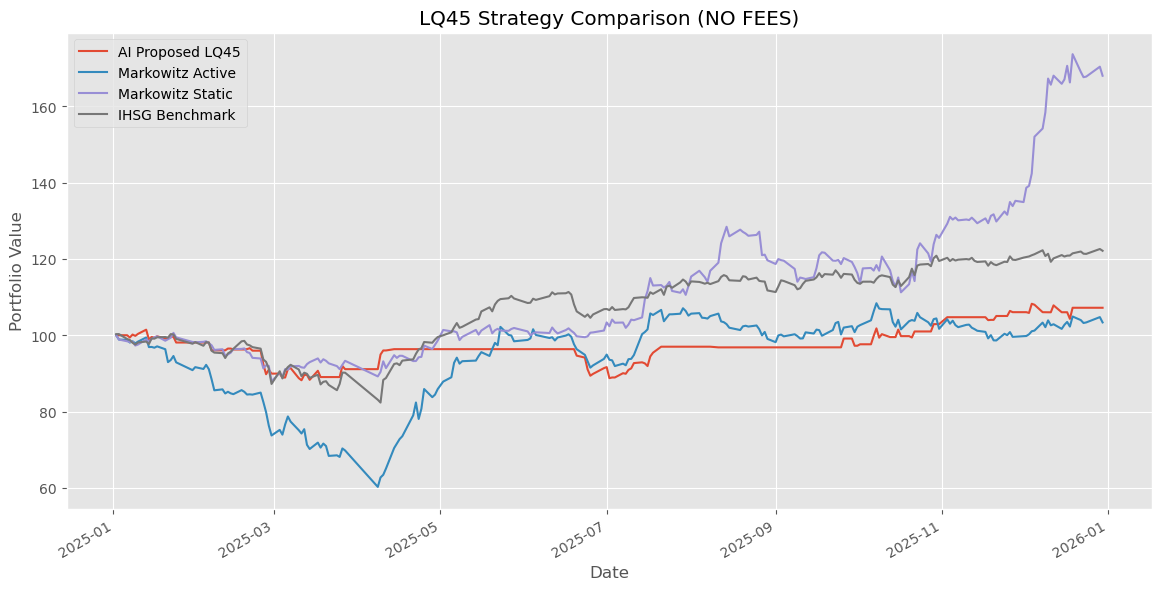

In [6]:
# Quick visualization in notebook
combined_df.plot(figsize=(14, 7), title="LQ45 Strategy Comparison (NO FEES)")
plt.ylabel("Portfolio Value")
plt.show()